# Anomaly Detection in Azure ML Studio

### About This Document

This document demonstrates how machine learning can be used to detect unusual or potentially fraudulent credit card transactions.

Instead of requiring deep technical knowledge, it walks through a practical example of how data can be analyzed to identify patterns that don’t look normal. These unusual patterns—called *anomalies*—can help organizations detect fraud, reduce financial risk, and improve security.

The notebook combines explanations with step-by-step processing of real transaction data. It shows how:

- Large volumes of transaction data can be analyzed efficiently  
- Patterns of normal behavior are identified  
- Suspicious or abnormal transactions are flagged automatically  

While the underlying implementation uses advanced data science tools, the goal of this document is to illustrate **how machine learning can support real-world decision-making**, particularly in financial fraud detection.

## End-to-End Pipeline Overview

![Pipeline Diagram](pipeline.jpg)

*Figure: End-to-end machine learning pipeline for fraud detection.*

## Azure ML Components and Their Role

| Azure ML Component        | Role in the Process                                                                 |
|--------------------------|--------------------------------------------------------------------------------------|
| Workspace                | Central place where all resources (data, models, experiments) are managed            |
| Datastore                | Secure storage connection to access raw transaction data                             |
| Dataset                  | Structured version of the data used for analysis and training                        |
| Compute Instance         | Development environment used to explore data and build the model (Jupyter Notebook) |
| Compute Cluster          | Scalable compute used to train models efficiently on larger datasets                 |
| Experiment               | Logical container to track runs, metrics, and results                                |
| Run                      | A single execution of training or data processing                                    |
| Environment              | Defines dependencies (Python packages, libraries) required to run the code           |
| Training Script / Notebook | Implements data preparation, model training, and evaluation logic                  |
| Model                    | The trained anomaly detection algorithm                                              |
| Pipeline                 | Orchestrates end-to-end steps (data prep → training → evaluation)                    |
| Endpoint (Deployment)    | Makes the model available for real-time or batch predictions                         |
| Monitoring               | Tracks model performance and detects drift or degradation over time                 |

## Workflow

### Step 1: Preparing the Tools

Before analyzing the data, we need to set up the tools required for the process.

This step loads a set of pre-built software components (called *libraries*) that help us work with data and build machine learning models. These libraries provide ready-made capabilities such as:

- Reading and organizing large datasets  
- Performing mathematical calculations and data transformations  
- Creating and training machine learning models  
- Visualizing results to better understand patterns and outcomes  

Once these tools are loaded, the notebook is ready to process data and begin identifying unusual or potentially fraudulent transactions.


In [5]:
# Step 1: Import Packages and Connect to your Azure Workspace
from azureml.core import Workspace, Dataset         # see https://pypi.org/project/azureml-core/
import pandas as pd                                 # see https://pandas.pydata.org/docs/
from sklearn.ensemble import IsolationForest        # see https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.IsolationForest.html
from sklearn.metrics import classification_report   # see https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html
from azureml.core.model import Model                # see https://docs.microsoft.com/en-us/python/api/azureml-core/azureml.core.model?view=azure-ml-py 

### Step 2: Accessing the Transaction Data

In this step, we retrieve the credit card transaction data that will be used for analysis.

The data is securely stored in Azure Machine Learning, which acts as a centralized and controlled environment for managing datasets. Instead of manually downloading files, the notebook connects directly to this secure storage and loads the data into the working environment.

This ensures that:
- The data is accessed in a consistent and reliable way  
- Security and access controls are maintained  
- Everyone working on the project uses the same trusted dataset  

Once loaded, the data becomes available for exploration and analysis. From here, we can begin examining transaction patterns and preparing the data to identify unusual or suspicious activity.
Retrieve the dataset from our existing workspace, and set this up for use with Pandas.


In [6]:
# You only need to run this if you've imported this notebook to Azure AI Machine Learning Studio - Notebook,
# in which case you'll also need to upload the config.json file to the same directory as this notebook,
# and then execute this code to determine the current working directory.
import os
print("Current working directory:", os.getcwd())
print("Files in this directory:", os.listdir())


Current working directory: /Users/gabriel/Library/CloudStorage/Dropbox/Gabriel/Education/CDL20_AI_and_Data_Literacy2_DataAnalytics/azureml-example/jupyter
Files in this directory: ['k-means.ipynb', '.DS_Store', 'requirements.txt', 'isolation_forest.pkl', 'House_Prices_Regression_Demo.ipynb', 'pipeline.jpg', 'anomaly_detection_creditcard.ipynb']


In [7]:
# if you're running locally then use this ...
path = None

# alternatively, if you're running in Azure AI Machine Learning Studio - Notebook, then use this ...
# (make sure to upload the config.json file to the same directory as this notebook)
#  and then execute this code to determine the current working directory.
path='/Users/gabriel/Library/CloudStorage/Dropbox/Gabriel/Education/CDL20_AI_and_Data_Literacy2_DataAnalytics/azureml-example/config.json'
ws = Workspace.from_config(path=path)
dataset = Dataset.get_by_name(ws, name='creditcard_fraud')
df = dataset.to_pandas_dataframe()
df.head()

If you run your code in unattended mode, i.e., where you can't give a user input, then we recommend to use ServicePrincipalAuthentication or MsiAuthentication.
Please refer to aka.ms/aml-notebook-auth for different authentication mechanisms in azureml-sdk.


{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe'}
{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe', 'activityApp': 'TabularDataset'}


Class DeploymentTemplateOperations: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.
/Users/gabriel/Library/Python/3.9/lib/python/site-packages/google/auth/__init__.py:54: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with critical bug fixes on a best-effort basis, but not with any other fixes or features. Please upgrade your Python version, and then update google-auth.
  warnings.warn(eol_message.format("3.9"), FutureWarning)
/Users/gabriel/Library/Python/3.9/lib/python/site-packages/google/oauth2/__init__.py:40: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with critical bug fixes on a best-effort basis, but not with any other fixes or features. Please upgrade your Python version, and then update google-auth.
  warnings.warn(eol_message.format("3.9"), FutureWarning)
Overriding of current TracerP

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,False
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,False
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,False
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,False
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,False


### Step 3: Preparing the Data

In this step, the data is adjusted and organized so it can be effectively used by the model.

First, the transaction amount is standardized. This means the values are rescaled so they are easier for the model to compare. Instead of working with raw dollar amounts (which can vary widely), the data is transformed into a consistent range. This helps the model treat all inputs more fairly and improves its ability to detect unusual patterns.

Next, the dataset is split into two parts:

- **Input data (X):** This includes all the information the model will use to analyze transactions, such as transaction details and derived features  
- **Target data (y):** This indicates whether each transaction is normal or fraudulent  

Some fields are intentionally excluded:
- The **"Class"** column is separated because it represents the known outcome (fraud or not) that the model will learn to predict  
- The **"Time"** column is removed because it does not add meaningful value for detecting fraud in this scenario  

This step ensures the model receives clean, well-structured data and clearly defined outcomes, allowing it to learn how to distinguish between normal and suspicious transactions.


In [4]:
df['Amount'] = (df['Amount'] - df['Amount'].mean()) / df['Amount'].std()
X = df.drop(columns=['Class', 'Time'])
y = df['Class']

### Step 4: Training the Model

In this step, the system learns how to recognize unusual or potentially fraudulent transactions by analyzing historical data.

Using the prepared dataset, a machine learning model is trained to understand what “normal” transaction behavior looks like. Once it has a baseline of normal activity, it becomes easier to identify transactions that deviate from that pattern.

Rather than relying on predefined rules, the model automatically discovers patterns by examining relationships in the data. For example, it may learn typical ranges, combinations of features, or behaviors that are common in legitimate transactions.

The training process involves:
- Feeding the model with transaction data (inputs) and known outcomes (fraud or not)  
- Allowing the model to identify patterns that distinguish normal from suspicious activity  
- Iteratively improving its internal logic to make better predictions over time  

In this particular approach, the model focuses on detecting anomalies—transactions that are significantly different from the norm—rather than trying to memorize every example of fraud. This is especially useful because fraudulent behavior can evolve and may not always follow known patterns.

By the end of this step, the model has effectively “learned” from past transactions and is ready to evaluate new ones, assigning a likelihood that a transaction is unusual or potentially fraudulent.

This trained model becomes the foundation for automated fraud detection and can be reused or further refined as new data becomes available.

#### Isolation Forest (Anomaly Detection)

Isolation Forest is a machine learning method used to identify unusual or suspicious data points, it focuses on identifying what is *different* from normal behavior. The idea is simple: unusual transactions are easier to “isolate” because they stand out from the rest of the data.

The algorithm works by repeatedly splitting the data into smaller groups. Transactions that can be separated quickly—using only a few steps—are considered more likely to be anomalies.

In practical terms:
- Normal transactions tend to be similar to many others and take longer to isolate  
- Unusual or potentially fraudulent transactions are different and get isolated quickly  

This makes Isolation Forest especially effective for fraud detection, where suspicious activity is rare and often does not follow predictable patterns.


In [5]:
model = IsolationForest(contamination=0.0017, random_state=42)
model.fit(X)
y_pred = model.predict(X)
y_pred = [1 if x == -1 else 0 for x in y_pred]

### Step 5: Evaluating the Model

After training the model, the next step is to assess how well it performs in identifying unusual or potentially fraudulent transactions.

This involves testing the model using known data—where we already know which transactions are legitimate and which are fraudulent—to see how accurately it can detect suspicious activity.

The evaluation focuses on questions such as:
- How many fraudulent transactions are correctly identified?  
- How often does the model incorrectly flag normal transactions as suspicious?  
- Is the model reliable enough to support real-world decision-making?  

Because fraud detection involves rare events, it is especially important to balance two outcomes:
- **Catching as much fraud as possible**  
- **Minimizing false alarms** that could disrupt normal customers  

#### Key Evaluation Metrics (Simplified)

To measure performance, several standard metrics are used:

- **Precision**  
  Of all the transactions flagged as suspicious, how many were actually fraud?  
  High precision means fewer false alarms.

- **Recall**  
  Of all the actual fraudulent transactions, how many did the model successfully detect?  
  High recall means fewer missed fraud cases.

- **F1-Score**  
  A combined measure that balances precision and recall.  
  Useful when you need a single score to evaluate overall effectiveness.

- **Support**  
  The number of actual examples for each category (e.g., how many fraud vs. non-fraud cases).  
  Helps provide context for how meaningful the results are.

These metrics together provide a balanced view of the model’s performance, helping determine whether it is effective and reliable enough for real-world use.


In [6]:
# Step 5: Evaluate Model
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

       False       1.00      1.00      1.00    284315
        True       0.29      0.28      0.28       492

    accuracy                           1.00    284807
   macro avg       0.64      0.64      0.64    284807
weighted avg       1.00      1.00      1.00    284807



### Step 6 (Optional): Registering the Model

In this step, the trained model is saved and recorded in a central system so it can be reused and shared.

Instead of keeping the model only within this notebook, it is registered in Azure Machine Learning. This acts like a secure catalog where models are stored, versioned, and managed over time.

By registering the model, we ensure that:
- The model can be easily accessed later without retraining  
- Different versions of the model can be tracked and compared  
- The model can be deployed to real-world applications (e.g., fraud detection systems)  
- Teams can collaborate using the same approved model  

This step is important when moving from experimentation to production, where consistency, governance, and traceability are required.


In [7]:
import joblib                                       # see https://joblib.readthedocs.io/en/latest/
                                                    #     Joblib is a set of tools to provide lightweight pipelining in Python
joblib.dump(model, 'isolation_forest.pkl')
Model.register(model_path='isolation_forest.pkl',
               model_name='creditcard_if_model',
               workspace=ws)


Registering model creditcard_if_model


Model(workspace=Workspace.create(name='CDL10', subscription_id='d279085b-fa85-4ec9-a027-9ef7712d6481', resource_group='gabriel-rg'), name=creditcard_if_model, id=creditcard_if_model:3, version=3, tags={}, properties={})

## Step 7: Visualizing Detected Anomalies

In this step, the results of the model are presented in a simple visual format to make them easier to understand.

After the model analyzes the transactions, it labels each one as either normal or potentially suspicious. This step summarizes those results by showing how many transactions fall into each category.

This is displayed as a chart making it easy to quickly see:
- The number of normal transactions  
- The number of transactions flagged as anomalies  

This visualization helps answer key questions such as:
- How common are suspicious transactions in the dataset?  
- Is the number of flagged anomalies reasonable or unexpectedly high?  

By presenting the results visually, stakeholders can quickly grasp the outcome of the analysis without needing to review raw data or technical outputs.


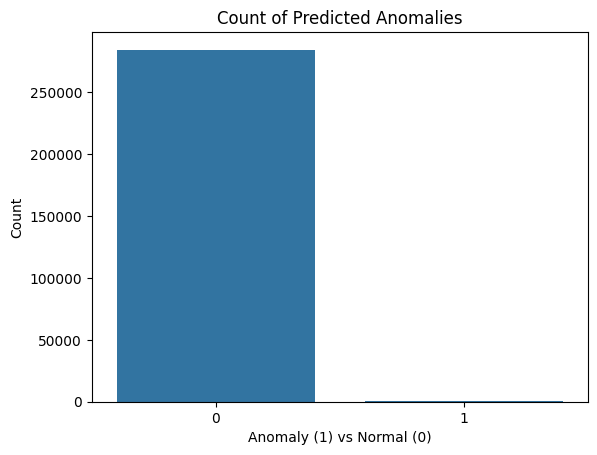

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Add predictions to the original dataframe
df['predicted_anomaly'] = y_pred

# Count of predicted anomalies
sns.countplot(x='predicted_anomaly', data=df)
plt.title('Count of Predicted Anomalies')
plt.xlabel('Anomaly (1) vs Normal (0)')
plt.ylabel('Count')
plt.show()


### Step 7 (continued): Comparing Transaction Amounts

In this step, we take a closer look at the transactions by comparing their amounts based on how the model classified them.

Instead of only counting how many transactions were flagged as suspicious, this visualization shows how transaction amounts differ between:
- Normal transactions  
- Transactions identified as potential anomalies  

This is displayed using a chart that highlights the distribution or range of transaction values in each group.

This helps answer questions such as:
- Are suspicious transactions generally higher in value?  
- Do anomalies tend to follow a different pattern than normal transactions?  
- Are there extreme or unusual amounts that stand out?  

By visualizing this comparison, we gain deeper insight into the characteristics of potentially fraudulent activity—not just how often it occurs, but how it behaves.


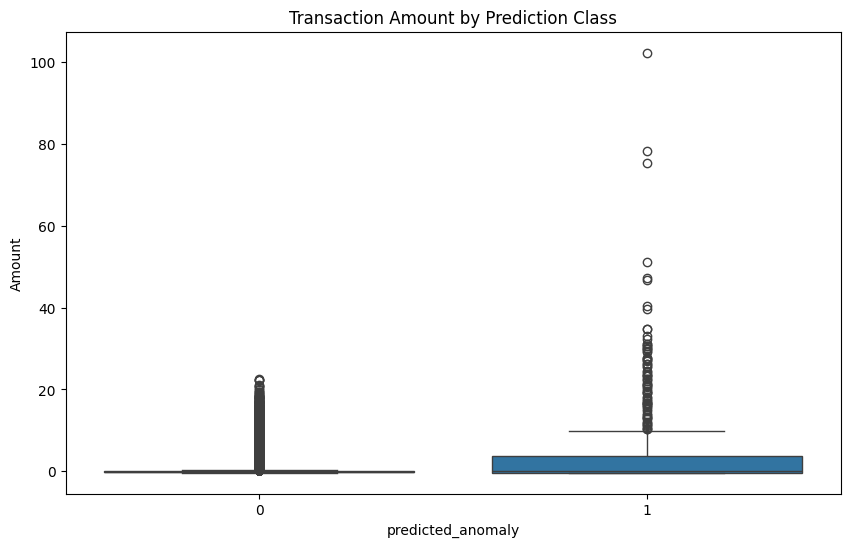

In [9]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='predicted_anomaly', y='Amount')
plt.title('Transaction Amount by Prediction Class')
plt.show()


### Step 7 (continued): Understanding What Drives Anomalies (SHAP Beeswarm Plot)

In this step, we go beyond identifying suspicious transactions and start to understand *why* the model flagged them as unusual.

To do this, we use a visualization called a **SHAP beeswarm plot**, which helps explain how different factors (features) influence the model’s decisions.

#### What is a SHAP Beeswarm Plot?

A SHAP beeswarm plot is a visual tool that shows how each feature in the data contributes to the model’s predictions.

- Each dot represents a single transaction  
- Each row represents a specific feature (for example, transaction amount or other derived attributes)  
- The position of the dot shows whether that feature pushed the prediction toward being more “normal” or more “anomalous”  
- The color indicates whether the feature value is relatively high or low  

Features are ordered by importance, so the most influential factors appear at the top.

#### Why This Matters

This visualization helps answer important questions such as:
- What factors most influence whether a transaction is flagged as suspicious?  
- Are certain patterns consistently associated with anomalies?  
- Can we explain the model’s behavior in a transparent and trustworthy way?  

By providing this level of insight, the SHAP beeswarm plot helps build confidence in the model and supports better decision-making.


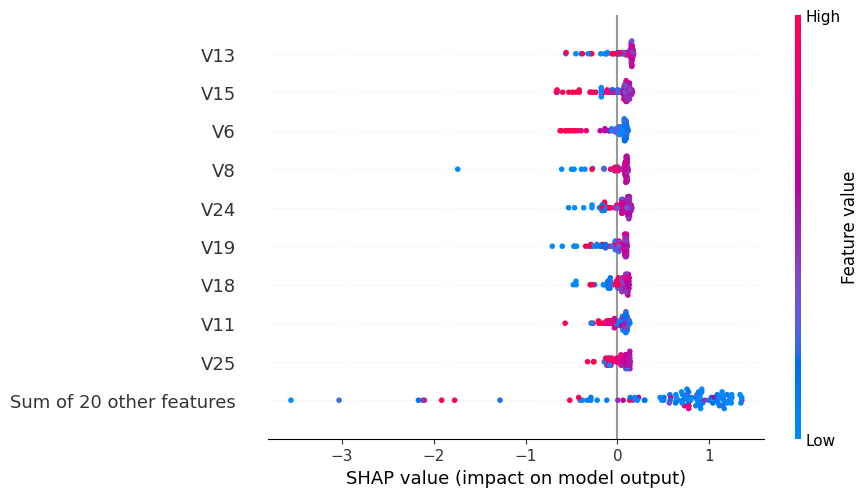

In [10]:
import shap

explainer = shap.Explainer(model, X)
shap_values = explainer(X[:100])
shap.plots.beeswarm(shap_values)